# Black Friday - Regresión con PyTorch
Notebook base para la entrega (preprocesamiento + modelo + TensorBoard).

In [2]:
%pip install torch tensorboard -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [2]:
def find_dataset_path():
    direct_candidates = [
        Path('SAA/blkfri_train.csv'),
        Path('../SAA/blkfri_train.csv'),
        Path('../../SAA/blkfri_train.csv'),
        Path('../../../SAA/blkfri_train.csv'),
        Path('blkfri_train.csv')
    ]
    for path in direct_candidates:
        if path.exists():
            return path

    # Búsqueda recursiva limitada por nombre de archivo
    for root in [Path('.'), Path('..'), Path('../..')]:
        if root.exists():
            matches = list(root.rglob('blkfri_train.csv'))
            if matches:
                return matches[0]

    raise FileNotFoundError('No se encontró blkfri_train.csv. Colócalo en SAA/ o ajusta la ruta.')

data_path = find_dataset_path()
df = pd.read_csv(data_path)
print('Dataset:', data_path)
print(df.shape)
df.head()

Dataset: blkfri_train.csv
(550068, 12)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [3]:
target_col = 'Purchase'
drop_cols = ['User_ID', 'Product_ID']

features_df = df.drop(columns=drop_cols + [target_col]).copy()
target = df[target_col].astype(np.float32).values

categorical_cols = ['Gender', 'Age', 'City_Category', 'Stay_In_Current_City_Years']
categorical_cols = [c for c in categorical_cols if c in features_df.columns]
numeric_cols = [c for c in features_df.columns if c not in categorical_cols]

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

X_train_full, X_test, y_train_full, y_test = train_test_split(
    features_df, target, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=SEED
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

X_train_t = X_train_t.toarray() if hasattr(X_train_t, 'toarray') else X_train_t
X_val_t = X_val_t.toarray() if hasattr(X_val_t, 'toarray') else X_val_t
X_test_t = X_test_t.toarray() if hasattr(X_test_t, 'toarray') else X_test_t

print('Train:', X_train_t.shape, 'Val:', X_val_t.shape, 'Test:', X_test_t.shape)

Train: (352043, 22) Val: (88011, 22) Test: (110014, 22)


In [4]:
batch_size = 1024

train_ds = TensorDataset(
    torch.tensor(X_train_t, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_val_t, dtype=torch.float32),
    torch.tensor(y_val, dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_test_t, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32).view(-1, 1)
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [11]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim, activation='relu', use_batchnorm=False, dropout=0.2):
        super().__init__()
        act = nn.ReLU if activation == 'relu' else nn.ELU

        blocks = []
        dims = [input_dim, 128, 96, 64]
        for i in range(len(dims) - 1):
            blocks.append(nn.Linear(dims[i], dims[i+1]))
            if use_batchnorm:
                blocks.append(nn.BatchNorm1d(dims[i+1]))
            blocks.append(act())
            blocks.append(nn.Dropout(dropout))

        blocks.append(nn.Linear(dims[-1], 1))
        self.net = nn.Sequential(*blocks)

    def forward(self, x):
        return self.net(x)

def train_model(config):
    model = MLPRegressor(
        input_dim=X_train_t.shape[1],
        activation=config['activation'],
        use_batchnorm=config['batchnorm'],
        dropout=config['dropout']
    ).to(device)

    criterion = nn.MSELoss()
    optimizer_name = config['optimizer'].lower()
    if optimizer_name == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    elif optimizer_name == 'rmsprop':
        optimizer = torch.optim.RMSprop(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=config['weight_decay'])

    log_dir = f"runs/{config['name']}_{int(time.time())}"
    writer = SummaryWriter(log_dir=log_dir)

    history = {'train_loss': [], 'val_loss': []}
    best_val = float('inf')
    best_state = None
    wait = 0

    for epoch in range(config['epochs']):
        model.train()
        train_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))

        if not np.isfinite(train_loss) or not np.isfinite(val_loss):
            break

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        writer.add_scalar('loss/train', train_loss, epoch)
        writer.add_scalar('loss/val', val_loss, epoch)
        if epoch % 5 == 0:
            for n, p in model.named_parameters():
                arr = p.detach().cpu().numpy()
                if arr.size == 0 or not np.isfinite(arr).all():
                    continue
                try:
                    writer.add_histogram(f'weights/{n}', arr, epoch)
                except ValueError:
                    pass

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= config['patience']:
            break

    writer.close()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, log_dir

def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
        preds = model(X_tensor).cpu().numpy().ravel()
    mse = mean_squared_error(y, preds)
    rmse = float(np.sqrt(mse))
    mae = mean_absolute_error(y, preds)
    r2 = r2_score(y, preds)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}, preds

In [6]:
base_config = {
    'name': 'pytorch_base',
    'activation': 'relu',
    'batchnorm': False,
    'optimizer': 'adam',
    'lr': 1e-3,
    'dropout': 0.2,
    'weight_decay': 1e-5,
    'epochs': 80,
    'patience': 10
}

model, history, log_dir = train_model(base_config)
metrics, preds = evaluate_model(model, X_test_t, y_test)
print('TensorBoard log:', log_dir)
print(metrics)

TensorBoard log: runs/pytorch_base_1772726227
{'MSE': 12020314.0, 'RMSE': 3467.0324486511518, 'MAE': 2608.06396484375, 'R2': 0.5216019749641418}


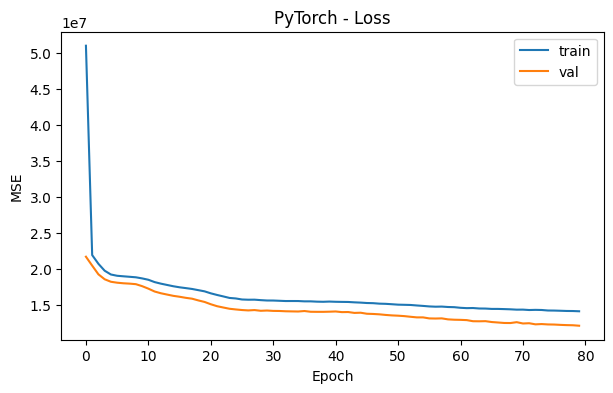

In [7]:
plt.figure(figsize=(7,4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('PyTorch - Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()

In [13]:
experiment_configs = [
    {**base_config, 'name': 'pytorch_bn', 'batchnorm': True, 'epochs': 60},
    {**base_config, 'name': 'pytorch_elu', 'activation': 'elu', 'epochs': 60},
    {**base_config, 'name': 'pytorch_sgd', 'optimizer': 'sgd', 'lr': 1e-3, 'epochs': 40}
]

results = []
for cfg in experiment_configs:
    m, h, l = train_model(cfg)

    with torch.no_grad():
        pred = m(torch.tensor(X_test_t, dtype=torch.float32).to(device)).cpu().numpy().ravel()

    if np.isnan(pred).any() or np.isinf(pred).any():
        results.append({
            **cfg,
            'MSE': np.nan,
            'RMSE': np.nan,
            'MAE': np.nan,
            'R2': np.nan,
            'status': 'diverged',
            'log_dir': l
        })
        continue

    met = {
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': float(np.sqrt(mean_squared_error(y_test, pred))),
        'MAE': mean_absolute_error(y_test, pred),
        'R2': r2_score(y_test, pred)
    }
    results.append({**cfg, **met, 'status': 'ok', 'log_dir': l})

pd.DataFrame(results)[['name', 'optimizer', 'activation', 'batchnorm', 'lr', 'epochs', 'MSE', 'RMSE', 'MAE', 'R2', 'status', 'log_dir']]

,name,optimizer,activation,batchnorm,lr,epochs,MSE,RMSE,MAE,R2,status,log_dir
0,pytorch_bn,adam,relu,True,0.001,60,9065908.0,3010.964629,2291.027588,0.639185,ok,runs/pytorch_bn_1772728514
1,pytorch_elu,adam,elu,False,0.001,60,14856896.0,3854.464425,2831.856689,0.408709,ok,runs/pytorch_elu_1772728768
2,pytorch_sgd,sgd,relu,False,0.001,40,NaN,NaN,NaN,NaN,diverged,runs/pytorch_sgd_1772729015


### TensorBoard
Ejecuta en terminal:
`tensorboard --logdir=runs`